# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [2]:
# Charger le dataset
df = pd.read_csv('data/sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.04 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   str    
 3   date            1020 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 43.0 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

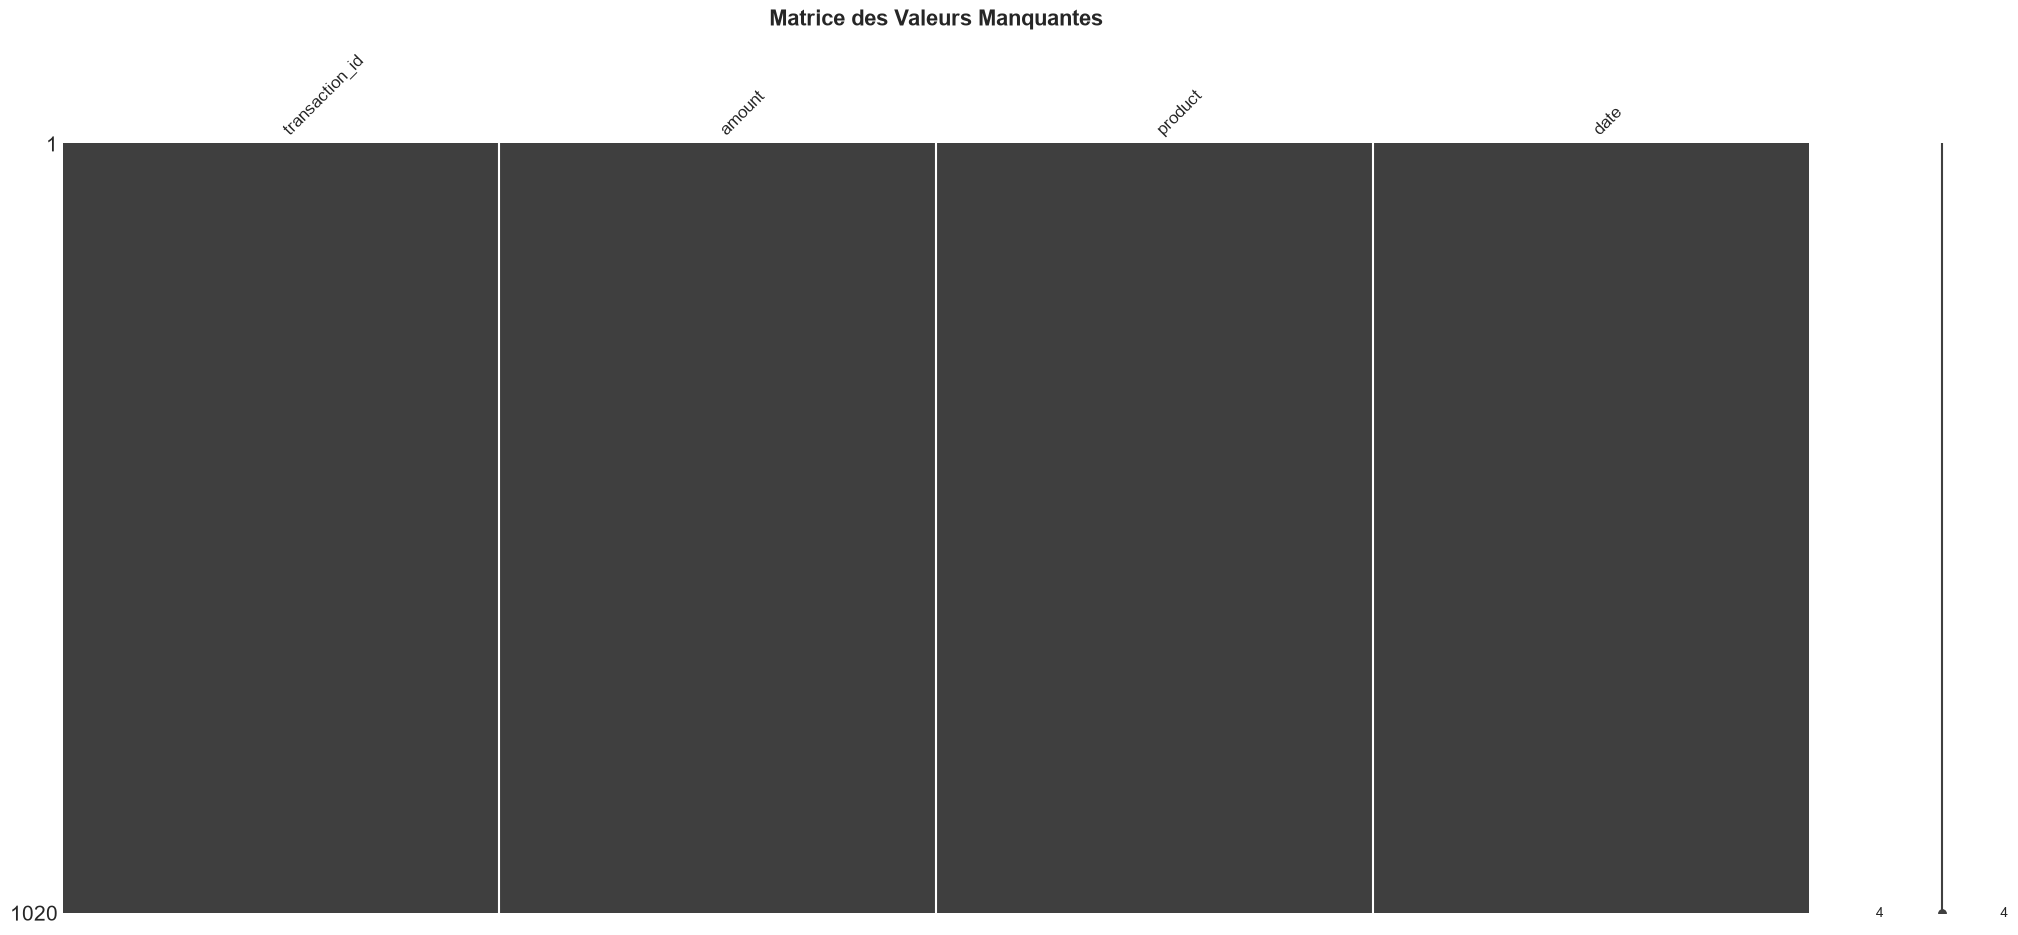


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [3]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


Réponses aux questions:
Question 1 :
Gros écarts, valeur médiane très basse par rapport aux valeurs les plus élevées, donc beaucoup de valeurs basses
valeur médiane =  3152.755 , valeur maximale = 185913.06
Question 2 : 0 montants négatifs
      transaction_id   amount product        date
3                  4  1580.76       A  2023-01-04
8                  9  5437.17       A  2023-01-09
9                 10  1126.61       A  2023-01-10
17                18  7585.80       A  2023-01-18
22                23 18062.63       A  2023-01-23
...              ...      ...     ...         ...
1008            1009  4215.12       A  2025-10-05
1009            1010  5373.15       A  2025-10-06
1013            1014 28224.83       A  2025-10-10
1014            1015 31943.65       A  2025-10-11
1019            1020  5875.88       A  2025-10-16

[320 rows x 4 columns]
Question 3 :
Le montant maxi (185913.06€) correspond au produit A pour lequel les autres montants sont très différents. La distribution 

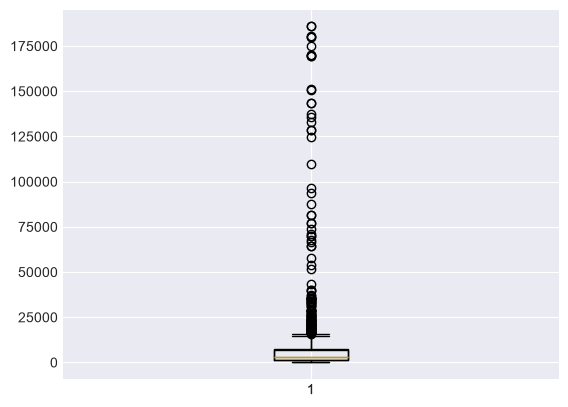

In [4]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
print("Question 1 :")
# sns.displot(df["amount"], binwidth=1000, kde=True)
plt.boxplot(df["amount"])
print("Gros écarts, valeur médiane très basse par rapport aux valeurs les plus élevées, donc beaucoup de valeurs basses")
print("valeur médiane = ",df["amount"].median(), ", valeur maximale =",df["amount"].max())
print(f"Question 2 : {(df["amount"]<0).sum()} montants négatifs")
print(df[df["product"]=="A"])
print("Question 3 :")
print(f"Le montant maxi ({df["amount"].max()}€) correspond au produit A pour lequel les autres montants sont très différents. La distribution du produit A est la suivante :")
plt.boxplot(df[df["product"]=="A"]["amount"])
print("Néanmoins on n'a pas de valeurs isolées, une analyse métier est nécessaire pour trancher.")
print("Question 4 :")
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Utilisation
outliersiqr, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliersiqr)}")
print("Question 5 :")
z_scores = np.abs(stats.zscore(df['amount']))
threshold = 3
# Détection des outliers
outliersz = df[z_scores > threshold]
print(f"Outliers détectés: {len(outliersz)}")
print("Question 6 :")
print("Nombre d'indexes communs :",len(outliersiqr.index.intersection(outliersz.index)))
print("Tous les outliers trouvés par la méthode Z-score sont présents parmi ceux trouvés par la méthode IQR.")
print("Question 7 :")
nbMt = len(df['amount'])
print(f"méthode IQR : {int(len(outliersiqr)/nbMt*100)}%, méthode Z-score : {int(len(outliersz)/nbMt*100)}%")
print("Question 8 :")
print(df["product"].filter(items=outliersiqr.index, axis=0).value_counts())
print(df["product"].filter(items=outliersz.index, axis=0).value_counts())
print("Pas de produit spécifique aux outliers")
print("Question 9 : voir avec le métier")
print("Question 10 :")
df_clean = df.drop(outliersz.index)
print(f"Moyenne avant : {df["amount"].mean()}, après : {df_clean["amount"].mean()}")
print("Même en n'enlevant que 2% des valeurs (Z-score), l'impact sur la moyenne est très sensible")

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


{'whiskers': [<matplotlib.lines.Line2D at 0x1df6372f620>,
 'caps': [<matplotlib.lines.Line2D at 0x1df6372f8c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1df6372f4d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1df6372fb60>],
 'fliers': [<matplotlib.lines.Line2D at 0x1df6372fcb0>],
 'means': []}

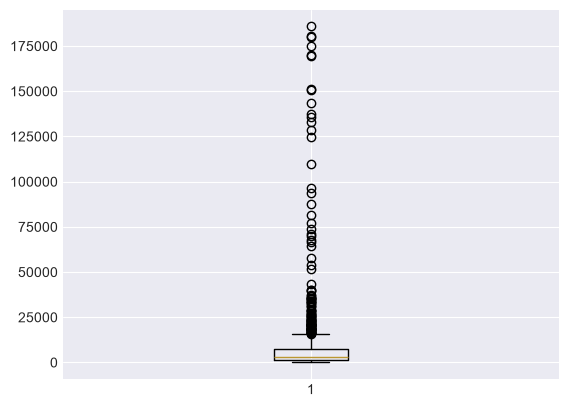

In [5]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# TODO: Écrivez votre code ici
plt.boxplot(df["amount"])


 Étape 1 complétée


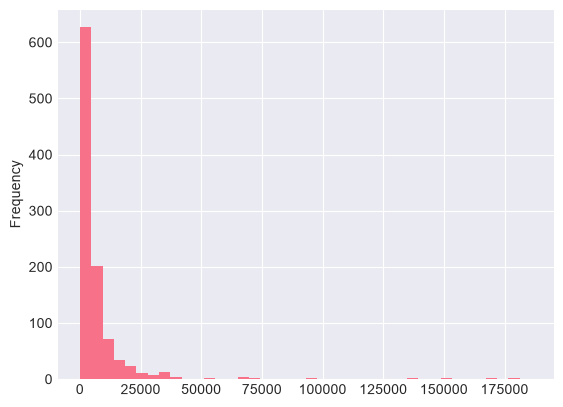

In [6]:
df["amount"].plot.hist(bins=40)
print(f" Étape 1 complétée")

In [7]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

# TODO: Écrivez votre code ici
print(df["amount"].describe())

# Vérification
print(f" Étape 2 complétée")

count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64
 Étape 2 complétée


In [9]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# TODO: Écrivez votre code ici
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliersiqr, lower, upper = detect_outliers_iqr(df, 'amount')
print(outliersiqr)

# Vérification
print(f" Étape 3 complétée")

      transaction_id    amount product        date
19                20  25093.72       B  2023-01-20
22                23  18062.63       A  2023-01-23
25                26  25983.52       C  2023-01-26
34                35 137548.12       C  2023-02-04
47                48  18994.26       A  2023-02-17
...              ...       ...     ...         ...
985              986  23679.30       A  2025-09-12
1000            1001  17420.53       A  2025-09-27
1007            1008  23837.57       B  2025-10-04
1013            1014  28224.83       A  2025-10-10
1014            1015  31943.65       A  2025-10-11

[105 rows x 4 columns]
 Étape 3 complétée


In [10]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

# TODO: Écrivez votre code ici
z_scores = np.abs(stats.zscore(df['amount']))
threshold = 3
# Détection des outliers
outliersz = df[z_scores > threshold]

print(outliersz)

# Vérification
print(f" Étape 4 complétée")

     transaction_id    amount product        date
34               35 137548.12       C  2023-02-04
55               56 124480.24       B  2023-02-25
69               70 185913.06       A  2023-03-11
71               72 151102.99       C  2023-03-13
82               83  76888.34       A  2023-03-24
148             149  93506.83       B  2023-05-29
329             330  73590.98       B  2023-11-26
373             374 132906.06       B  2024-01-09
387             388 150905.45       C  2024-01-23
404             405 179794.36       A  2024-02-09
545             546  71197.43       C  2024-06-29
652             653 109483.05       C  2024-10-14
678             679 128707.57       A  2024-11-09
680             681 169502.21       A  2024-11-11
709             710 180712.11       C  2024-12-10
729             730  87570.18       B  2024-12-30
801             802 135761.90       B  2025-03-12
813             814 174924.56       B  2025-03-24
898             899 170000.52       A  2025-06-17


In [14]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

# TODO: Écrivez votre code ici
print("Nombre d'indexes communs :",len(outliersiqr.index.intersection(outliersz.index)))
print("Tous les outliers trouvés par la méthode Z-score sont présents parmi ceux trouvés par la méthode IQR.")
print(f"Il y a {round(len(outliersiqr)/len(outliersz),1)} fois plus d'outliers iqr que de Z")

# Vérification
print(f" Étape 5 complétée")

Nombre d'indexes communs : 22
Tous les outliers trouvés par la méthode Z-score sont présents parmi ceux trouvés par la méthode IQR.
Il y a 4.8 fois plus d'outliers iqr que de Z
 Étape 5 complétée


In [ ]:
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

# TODO: Écrivez votre code ici
print("Pour éviter d'éliminer trop de valeurs, on retient les outliers de la méthode Z-score.")
print("La suppression des outliers fausse moins le jeu de données que le capping.")

# Vérification
print(f" Étape 6 complétée")

 Étape 7 complétée


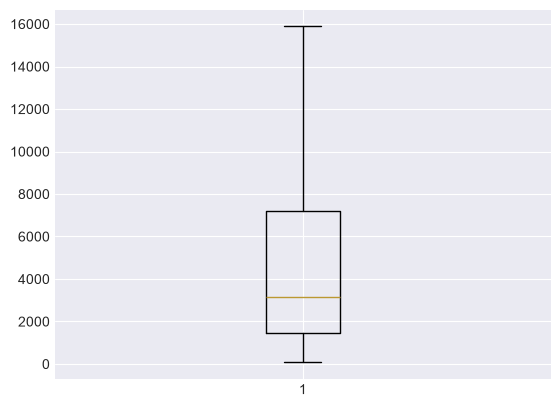

In [16]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================
df_clean = df.copy()

# limitation des valeurs avec le lower et upper donnés par la méthode IQR
df_clean['amount'] = df['amount'].clip(lower=lower, upper=upper)

# Vérification
print(f" Étape 7 complétée")

 Étape 8 complétée


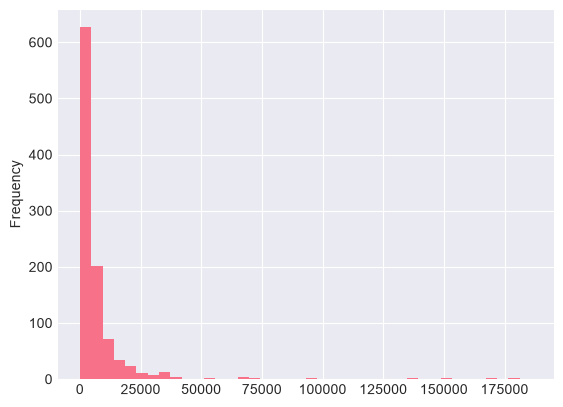

In [21]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

# TODO: Écrivez votre code ici
#plt.boxplot(df_clean["amount"])

df["amount"].plot.hist(bins=40)


# Vérification
print(f" Étape 8 complétée")

<Axes: ylabel='Frequency'>

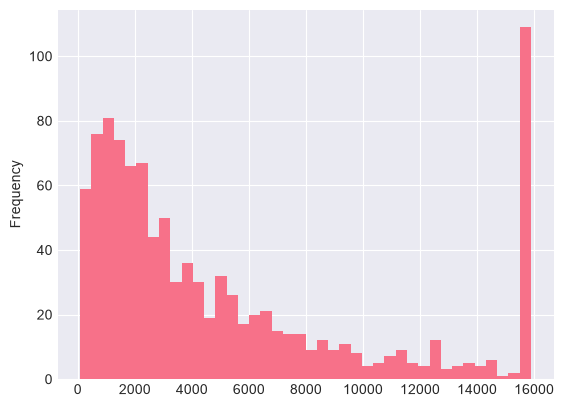

In [22]:
df_clean["amount"].plot.hist(bins=40)

In [30]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

# TODO: Écrivez votre code ici
print(f"Impact sur la moyenne : avant = {round(df.amount.mean(),2)}, après = {round(df_clean.amount.mean(),2)}")
print(f"Impact sur la médiane : avant = {round(df.amount.median(),2)}, après = {round(df_clean.amount.median(),2)}")
print("Résultat non surprenant car le fait que les hautes valeurs soient loins ou proches de la médiane n'en change pas la valeur, ce qui n'est pas du tout le cas pour la moyenne où chaque valeur compte.")

# Vérification
print(f" Étape 9 complétée")

Impact sur la moyenne : avant = 8616.96, après = 5181.4
Impact sur la médiane : avant = 3152.76, après = 3152.76
Résultat non surprenant car le fait que les hautes valeurs soient loins ou proches de la médiane n'en change pas la valeur, ce qui n'est pas du tout le cas pour la moyenne où chaque valeur compte.
 Étape 9 complétée


In [31]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

# TODO: Écrivez votre code ici
print("Cf. rapport final")

# Vérification
print(f" Étape 10 complétée")

Cf. rapport final
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [38]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': len(outliersiqr),
    'Transformations_appliquées': [f"Application du clapping à la colonne amount : montants limités à la valeur {upper}"]
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n✅ TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (1020, 4)
Dimensions_finales...................... (1020, 4)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 105
Transformations_appliquées.............. ['Application du clapping à la colonne amount : montants limités à la valeur 15891.685']

✅ TP terminé avec succès!


In [34]:
(df["amount"]!=df_clean["amount"]).sum()

np.int64(105)

In [53]:
df_high = df[df["amount"]>40000]

<Axes: ylabel='Frequency'>

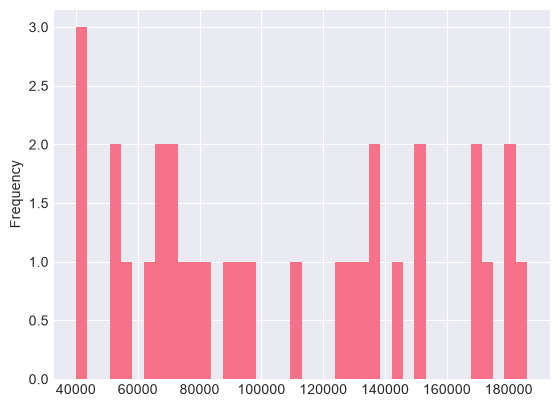

In [54]:
df_high["amount"].plot.hist(bins=40)

In [42]:
len(df_high)

32

In [48]:
df_clean2 = df.loc[[index for index in df.index if index not in outliersz.index]]

<Axes: ylabel='Frequency'>

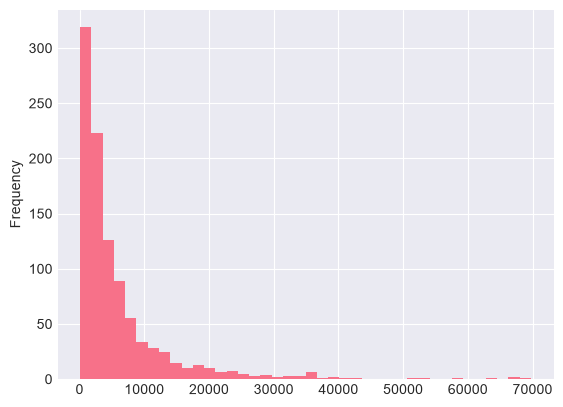

In [50]:
df_clean2.amount.plot.hist(bins=40)